# Setup

In [1]:
%load_ext autoreload
%autoreload 2
%cd -q ..
from impl.utils.explain import vectorize, generate_rules, model_fit, explain, scoring

# Prepare data

In [2]:
import pickle
from pathlib import Path

projects = [
    "1748884695969-ccea-d240fc", "1748941748026-ccea-b9ac6b", "1748989829337-ccea-4ec741", "1749038770422-ccea-42ed4d",
    "1749777922892-ccea-2c25d2", "1749814642920-ccea-de1f87", "1749886823824-ccea-649444", "1749923655258-ccea-1ba284",
    "1751198102877-ccea-1addfe", "1751208800030-ccea-a4ce3b", "1750185618111-ccea-6e8d47", "1750198943587-ccea-7053fc",
    "1750206690539-ccea-5685b2", "1750216454876-ccea-7d20e2", "1750227193443-ccea-78d6d1", "1750239856908-ccea-022c28",
    "1750251392201-ccea-cf8492", "1750268611439-ccea-719936", "1750277989099-ccea-b24329", "1748920884019-ga-b8096d",
    "1748973401212-ga-159d20", "1749020894373-ga-0c91c0", "1749070990957-ga-e5c457", "1749117177309-ga-e90e3a",
    "1749801622497-ga-1bf740", "1749865564502-ga-d4aeee", "1749911224188-ga-398954", "1749948108048-ga-cf2ad2",
    "1748904187579-rs-eb1239", "1748957118058-rs-2e552d", "1749004788416-rs-6bf5f1", "1749054600895-rs-2ed24b",
    "1749101043616-rs-24f811", "1749789337635-rs-395f0a", "1749825433865-rs-6f42c1", "1749852996207-rs-73049d",
    "1749897744564-rs-122ef9", "1749934847144-rs-a62c00", "1750434085129-ccea-ddb606", "1750449704726-ccea-5b378e",
    "1750463599493-ccea-3174c7", "1750474241344-ccea-de114c", "1750486589729-ccea-d7ee1e", "1750497161663-ccea-e0eee8",
    "1751223236951-ccea-ca103a", "1751231897173-ccea-a652fa", "1751243485332-ccea-36643e", "1751274772053-ccea-ac5042",
    "1750785163861-ccea-21aab6", "1750803393939-ccea-e46291", "1750816760201-ccea-a491e1", "1750840993246-ccea-b56d46",
    "1750864129037-ccea-b6c460", "1750874763838-ccea-c37984", "1751036741158-ccea-8dbdc7", "1751052499693-ccea-37549d",
    "1751064557270-ccea-8d3741", "1751327671761-ccea-fa8901",
]

violations, non_violations = [], []
for project in projects:
    for solution_file in Path("out/results", project, "solutions").rglob("evaluated*"):
        for solution in pickle.loads(solution_file.read_bytes()):
            if solution.is_violated:
                violations.append(solution)
            elif not solution.is_violated and solution.fitness.valid:
                non_violations.append(solution)
if len(non_violations) > len(violations):
    import random

    non_violations = random.sample(non_violations, len(violations))
solutions = violations + non_violations
print(f"#violations: {len(violations)}, #non-violations: {len(non_violations)}, total: {len(solutions)}")

#violations: 597, #non-violations: 443, total: 1040


# Vectorization

In [3]:
X, y, y_v1, y_v2, features = vectorize(solutions, mode="stats")

# Train models

In [ ]:
best_model = model_fit(X, y)

In [ ]:
best_model_v1 = model_fit(X, y_v1)

In [ ]:
best_model_v2 = model_fit(X, y_v2)

# Load models

In [11]:
import joblib

best_model = joblib.load("out/exp_results/1752513402321/best_model.pkl")
# best_model_v1 = joblib.load("out/exp_results/1751041555795/best_model.pkl")
# best_model_v2 = joblib.load("out/exp_results/1751042068929/best_model.pkl")

# RuleFit

In [21]:
rulefit = generate_rules(X, y, features)
rules = rulefit._get_rules()
rules[rules.coef != 0].sort_values("support", ascending=False).style.background_gradient(cmap="viridis")

,rule,type,coef,support,importance
495,source_traj_1q_yaw > -449.72627 and source_traj_middle_yaw > -449.64967 and follow_up_num_static <= 17.5,rule,0.271041,0.970192,0.046092
496,source_traj_end_yaw > -575.31882 and follow_up_ego_model_21 <= 0.5 and source_traj_1q_y > -50.38745,rule,0.232651,0.939423,0.055500
498,source_traj_middle_y > -68.12496 and source_ego_model_21 <= 0.5,rule,0.096869,0.932692,0.024271
497,follow_up_ego_yaw <= 179.80878 and follow_up_traj_middle_x <= 74.14797,rule,0.230247,0.914423,0.064409
500,source_vehicle_None_speed_max <= 7.17654 and follow_up_traj_1q_yaw > -439.95219 and follow_up_ego_model_21 <= 0.5,rule,0.180405,0.909615,0.051728
494,source_traj_3q_y > -50.01269 and source_vehicle_None_radius_mean <= 48.84128 and follow_up_traj_middle_y > -64.00927,rule,0.123838,0.840385,0.045356
493,follow_up_traj_middle_z > -0.00385 and follow_up_traj_end_y <= 87.72931,rule,-0.016498,0.834615,0.006129
499,source_traj_1q_yaw > -449.72627 and source_traj_end_x <= 89.96955 and follow_up_static_None_yaw_median > -106.37935 and source_brightness > 2.5,rule,0.052584,0.775000,0.021958
501,source_traj_1q_yaw <= -2.70488 and follow_up_traj_1q_y > -50.38745 and follow_up_num_static <= 17.5 and follow_up_ego_model_9 <= 0.5,rule,0.149574,0.306731,0.068974
492,follow_up_traj_middle_x <= -0.37136 and follow_up_traj_end_y <= -52.23943 and source_brightness <= 3.0,rule,-0.033291,0.026923,0.005388


## RQ3: MASE comparison

In [ ]:
from collections import defaultdict
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from imodels import RuleFitRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
import numpy as np

models = {
    "rulefit": RuleFitRegressor,
    "rf": RandomForestRegressor,
    "gbdt": GradientBoostingRegressor
}
metrics = defaultdict(lambda: defaultdict(list))

for _ in range(500):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

    # Baseline.
    y_pred_median = np.full_like(y_val, fill_value=np.median(y_train))
    metrics["baseline"]["mae"].append(mean_absolute_error(y_val, y_pred_median))

    for name, cls in models.items():
        model = cls()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        metrics[name]["mae"].append(mean_absolute_error(y_val, y_pred))
        metrics[name]["mase"].append(mean_absolute_error(y_val, y_pred) / mean_absolute_error(y_val, y_pred_median))

with open("out/mase_metrics.pkl", "wb") as f:
    pickle.dump(dict(metrics), f)

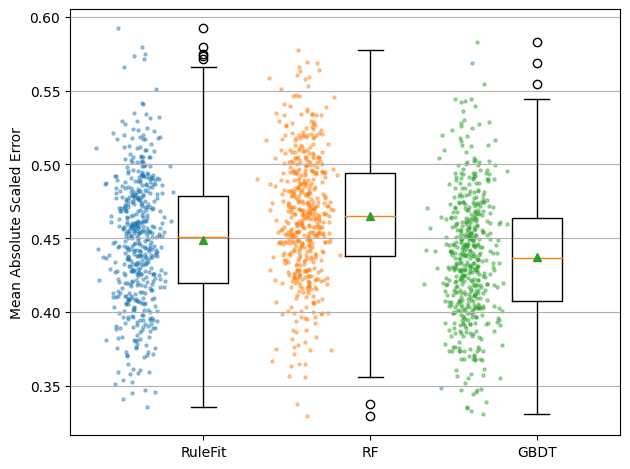

In [52]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
values = [metrics[name]["mae"] for name in ("rulefit", "rf", "gbdt")]
ax.boxplot(values, labels=["RuleFit", "RF", "GBDT"], showmeans=True)
for i, value in enumerate(values):
    ax.scatter(np.random.normal(i + 0.6, 0.08, len(value)), value, alpha=0.4, s=5)
ax.grid(axis="y")
ax.set_ylabel("Mean Absolute Scaled Error")
plt.tight_layout()
plt.savefig("out/visualizations/mase.png")

## RQ3: RAD comparison

In [6]:
import numpy as np

def _evaluate_rules(_rules, _X, _y):
    _y = np.array(_y)
    for _i, _row in _rules[(_rules.coef != 0) & (_rules.type != "linear")].iterrows():
        _rule = _row["rule"]
        _rule_mask = np.zeros(_y.size, dtype=bool)
        _rule_mask[_X.query(_rule).index] = True
        _rule_score = _score(_y, _rule_mask, _row["coef"])
        # _rule_score = _y[_rule_mask].mean() - _y[~_rule_mask].mean()
        _n = len(_y)
        _base_mask = np.array([True] * (_n // 2) + [False] * (_n - _n // 2))
        _rand_score = 0
        _times = 1000
        for _ in range(_times):
            # _rand_score += _score(_y, np.random.permutation(_base_mask), _row["coef"])
            _mask = np.random.permutation(_base_mask)
            _rand_score = _y[_mask].mean() - _y[~_mask].mean()
        _rand_score /= _times
        rules.loc[_i, "score_rule"] = _rule_score
        rules.loc[_i, "score_random"] = _rand_score

def _score(_y, _mask, _coef):
    _delta_mean = _y[_mask].mean() - _y[~_mask].mean()
    _sign = np.sign(_delta_mean * _coef)
    _ratio = np.abs(_delta_mean - _coef)
    return _sign * _ratio

In [7]:
import pandas as pd

dfs = []
for _ in range(500):
    rulefit = generate_rules(X, y, features)
    rules = rulefit._get_rules()
    _evaluate_rules(rules, X, y)
    dfs.append(rules)
df = pd.concat(dfs)
df = df[(df.coef != 0) & (df.type != "linear")]

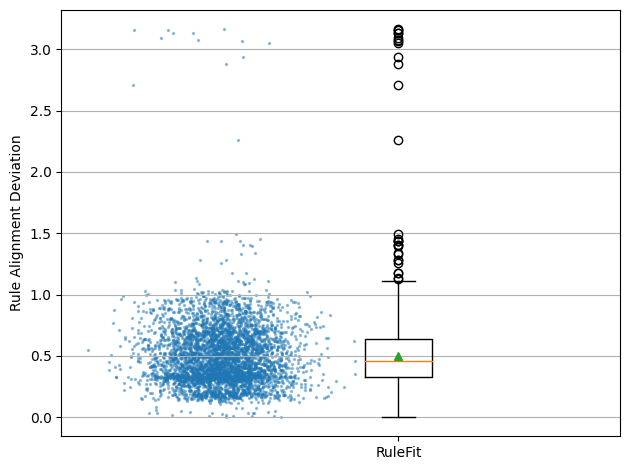

In [49]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.boxplot(df["score_rule"], labels=["RuleFit"], showmeans=True)
ax.scatter(np.random.normal(0.6, 0.08, len(df["score_rule"])), df["score_rule"], alpha=0.4, s=2)
ax.grid(axis="y")
ax.set_ylabel("Rule Alignment Deviation")
plt.tight_layout()
plt.savefig("out/visualizations/rad.png")

# SHAP

In [ ]:
explanation = explain(best_model, X)

In [ ]:
scoring(best_model_v1, best_model_v2, X)